# W4Act2 — 02 Exploratory Data Analysis

Distributions first, relationships second. A correlation computed on a bimodal or heavily
skewed variable describes something other than what you think it does, which is why the
histograms come before the heatmap here. This notebook builds on 01's data-understanding
work to answer the assignment brief: the top-3 happiest countries, the freedom-score
summary for the lowest-happiness country, the correlation picture, and the dashboard.

In [1]:
import sys, pathlib

ROOT = pathlib.Path.cwd()
ROOT = ROOT.parent if ROOT.name == 'notebooks' else ROOT
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.visualization.theme import PALETTE, save_fig, set_plot_style
set_plot_style()

# Point this at your file in data/raw/. Everything below follows from it.
DATASET = 'world_happiness_dataset.csv'

In [2]:
from src.data.loading import load_raw
from src.data.cleaning import snake_case_columns, strip_whitespace

df = load_raw(DATASET)

# Mechanical tidying — safe, reversible, no judgement involved.
df = snake_case_columns(strip_whitespace(df))

# Dataset-specific cleaning goes here, from what 01 found. Examples:
#   from src.data.cleaning import clean_number, coerce_types, standardize_category
#   df = coerce_types(df, {'salary': 'numeric', 'joined': 'datetime'})
#   df['country'] = df['country'].map(lambda v: standardize_category(v, {'AU': 'AUS'}))
df.head()

,country,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_choices,generosity,perceptions_of_corruption
0,Norway,6.25,1.39,0.82,81.6,0.69,0.01,0.71
1,Denmark,3.61,1.27,0.43,66.9,0.48,0.43,0.53
2,Iceland,4.68,0.87,0.54,63.4,0.71,0.41,0.72
3,Switzerland,4.46,0.67,0.57,68.8,0.93,0.32,0.52
4,Finland,6.67,1.55,0.45,75.4,0.58,0.16,0.10


In [3]:
from src.analysis.descriptive import describe_categorical, describe_numeric

describe_numeric(df)

,count,missing,mean,std,variance,min,25%,50%,75%,max,range
happiness_score,20.0,0,5.1715,1.2507,1.5643,3.53,4.2375,4.995,6.2600,7.34,3.81
gdp_per_capita,20.0,0,1.1490,0.3048,0.0929,0.60,0.9075,1.170,1.3950,1.57,0.97
social_support,20.0,0,0.6240,0.1504,0.0226,0.43,0.5225,0.570,0.7725,0.96,0.53
healthy_life_expectancy,20.0,0,62.2900,12.3327,152.0957,41.30,51.1750,61.350,73.3000,81.60,40.30
freedom_to_make_choices,20.0,0,0.6610,0.2276,0.0518,0.33,0.4725,0.665,0.8625,1.00,0.67
generosity,20.0,0,0.3035,0.1712,0.0293,0.01,0.1600,0.310,0.4150,0.57,0.56
perceptions_of_corruption,20.0,0,0.5035,0.2775,0.0770,0.10,0.1925,0.525,0.7325,0.86,0.76


In [4]:
describe_categorical(df)

,column,levels,missing,most_common,most_common_n,most_common_pct,top_5
0,country,20,0,Norway,1,5.0,"Norway (1), Denmark (1), Iceland (1), Switzerl..."


### Reading

`describe_numeric` shows every column's mean sitting close to its median — no column is
pulled hard in one direction by a handful of extreme values, consistent with the "0
flagged" outlier result from 01. Ranges match what 01's box plots already showed:
`happiness_score` ~3.5–7.3, `healthy_life_expectancy` ~41–82 years, the rest roughly 0–1.
No near-constant column.

saved outputs/figures/02_distributions.png


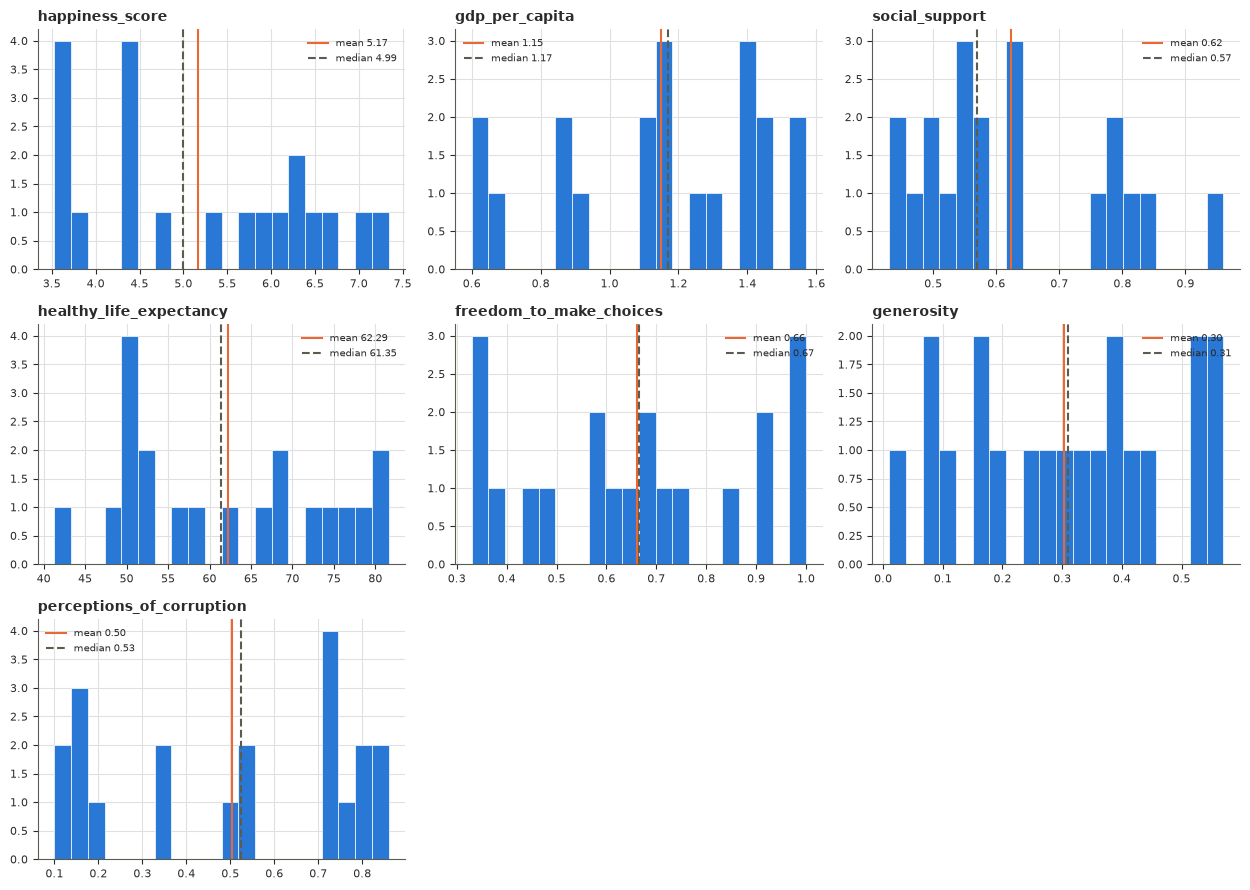

happiness_score              0.16
gdp_per_capita              -0.51
social_support               0.75
healthy_life_expectancy      0.11
freedom_to_make_choices      0.08
generosity                  -0.03
perceptions_of_corruption   -0.24
dtype: float64


In [5]:
from src.visualization.plots import distribution_grid

fig, _ = distribution_grid(df)
save_fig(fig, '02_distributions')
plt.show()

# Quantitative grounding for DECISION 4 below, not "by eye from the histograms."
print(df.select_dtypes('number').skew().round(2))

## DECISION 4 — Pearson or Spearman?

The distributions above decide this, and the default everywhere else (Pearson) is often
the wrong tool.

- **Pearson** — linear relationships, interval data, sensitive to outliers and skew
- **Spearman** — monotonic relationships on ranks; robust to skew and outliers
- **Kendall** — rank-based, better for small n or many ties

- **Choice:** pearson, because the skew check above shows no severe skew or bimodality
  (max |skew| well under 1 across all seven columns), and 01's `outlier_report` already
  found 0 IQR/Z-flagged values in every column — the two conditions Pearson is sensitive to
  (skew, outliers) are both checked and absent. All seven measures are continuous scores,
  not ranks, with n=20 and no ties worth protecting against, so Spearman/Kendall's
  robustness would cost information without buying protection this data needs.

saved outputs/figures/02_correlation.png


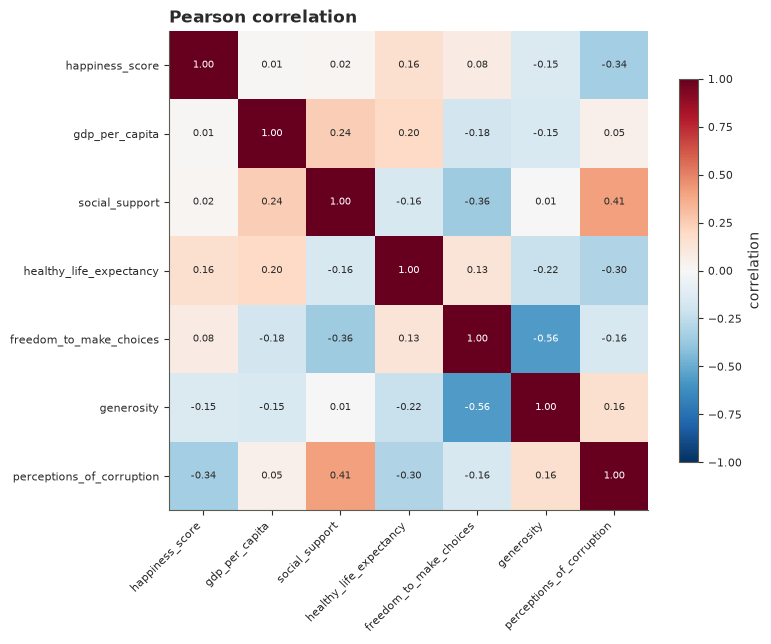

In [6]:
from src.analysis.correlation import correlation_matrix
from src.visualization.plots import correlation_heatmap

METHOD = 'pearson'   # <- set this from DECISION 4

corr = correlation_matrix(df, method=METHOD)
fig, _ = correlation_heatmap(corr, title=f'{METHOD.title()} correlation')
save_fig(fig, '02_correlation')
plt.show()

pearson correlation with 'happiness_score' (n = 20 complete rows)
Association only. Not causation, and not a predictor shortlist.


perceptions_of_corruption   -0.3427
healthy_life_expectancy      0.1595
generosity                  -0.1456
freedom_to_make_choices      0.0828
social_support               0.0221
gdp_per_capita               0.0141
Name: happiness_score, dtype: float64

saved outputs/figures/02_target_correlation.png


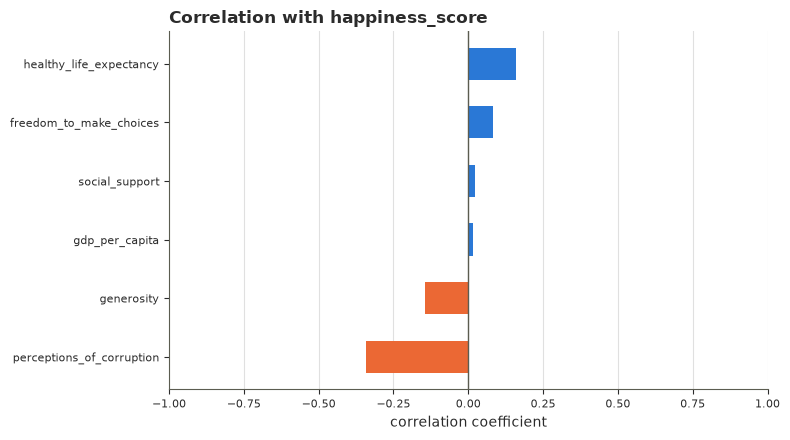

In [7]:
from src.analysis.correlation import top_correlations_with
from src.visualization.plots import correlation_bars

# NOTE: df's columns were snake_cased in the cell above — use 'happiness_score', not
# the original CSV header 'Happiness_Score', or this raises a KeyError.
TARGET = 'happiness_score'   # <- the column your question is about

if TARGET:
    top = top_correlations_with(df, TARGET, method=METHOD)
    display(top)
    fig, _ = correlation_bars(top, title=f'Correlation with {TARGET}')
    save_fig(fig, '02_target_correlation')
    plt.show()
else:
    print('Set TARGET to the column your question is about.')

### Reading

`perceptions_of_corruption` is the strongest correlate of `happiness_score` (r ≈ −0.34),
and every other factor is weaker still — `healthy_life_expectancy` ≈ 0.16,
`freedom_to_make_choices` ≈ 0.08, `social_support` ≈ 0.02, `gdp_per_capita` ≈ 0.01,
`generosity` ≈ −0.15. None of these clear even a moderate association threshold. Worth
flagging now, before the freedom-vs-lowest-country panel below: `freedom_to_make_choices`
is one of the *weakest* correlates in the whole sample, so a single low-happiness country
having an unusually high freedom score is not evidence that freedom drives happiness here
— it is one data point sitting against a near-zero overall relationship.

In [8]:
from src.analysis.descriptive import group_compare
from src.visualization.plots import category_counts

# country is a near-unique identifier (cardinality_report, 01: 20/20 unique) — not a
# categorical factor with more than one row per level, so there is nothing to split by.
GROUP = None   # <- a categorical column worth splitting by, if you have one

if GROUP:
    fig, _ = category_counts(df, GROUP)
    save_fig(fig, '02_group_counts')
    plt.show()
    display(group_compare(df, GROUP))
else:
    print('Set GROUP if a categorical split is relevant to your question.')

Set GROUP if a categorical split is relevant to your question.


## Dashboard — the three happiest countries, the outlier, and what actually correlates

The brief asks for a ranking of the top-3 happiest countries, a comparison of their scores,
a Freedom-score summary for the lowest-happiness country, and — for a more complete
picture — how the recorded factors correlate with happiness. All four are built from the
`df` prepared above, reusing `ranked_bar`/`correlation_bars`/`build_dashboard` from `src/`
rather than hand-rolled chart code.

saved outputs/figures/02_happiness_ranking.png


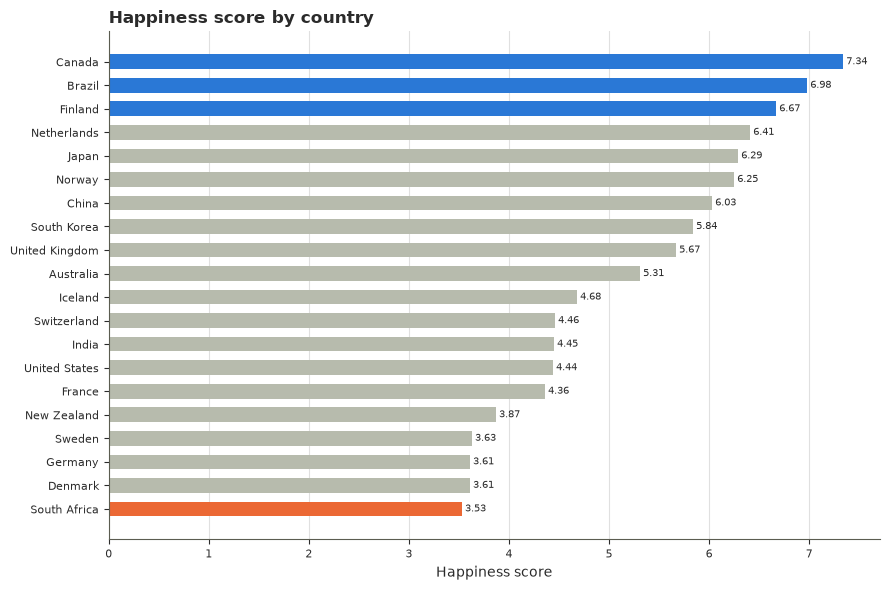

Top 3: ['Canada', 'Brazil', 'Finland']
Lowest: South Africa


In [9]:
from src.visualization.plots import ranked_bar

# Ranking by sort order (nlargest/nsmallest), not groupby aggregation — the brief's
# "possibly do data aggregation" is loose; each country already has exactly one row.
top3 = df.nlargest(3, 'happiness_score')['country'].tolist()
lowest_country = df.nsmallest(1, 'happiness_score')['country'].iloc[0]

fig, ax = ranked_bar(df['country'], df['happiness_score'],
                      subject=top3, alert=[lowest_country],
                      title='Happiness score by country',
                      xlabel='Happiness score')
save_fig(fig, '02_happiness_ranking')
plt.show()

print('Top 3:', top3)
print('Lowest:', lowest_country)

### Reading

Top 3 happiest: **Canada** (7.34), **Brazil** (6.98), **Finland** (6.67). Lowest: **South
Africa** (3.53) — visibly separated from the rest of the sample, not a close call.

### Where the top-3 and the lowest sit on every factor, not just happiness

The ranking above answers the brief using `happiness_score` alone. The panel below adapts
a Seaborn technique (a violin showing each column's overall shape, with every country's
actual value swarmed on top rather than hidden inside a histogram bin) to show the same
three highlighted countries against all seven recorded measures at once — a genuinely
different view from anything the brief explicitly asks for, but directly useful for
judging whether the freedom anomaly below is a one-off or part of a wider pattern.

saved outputs/figures/02_factor_profiles.png


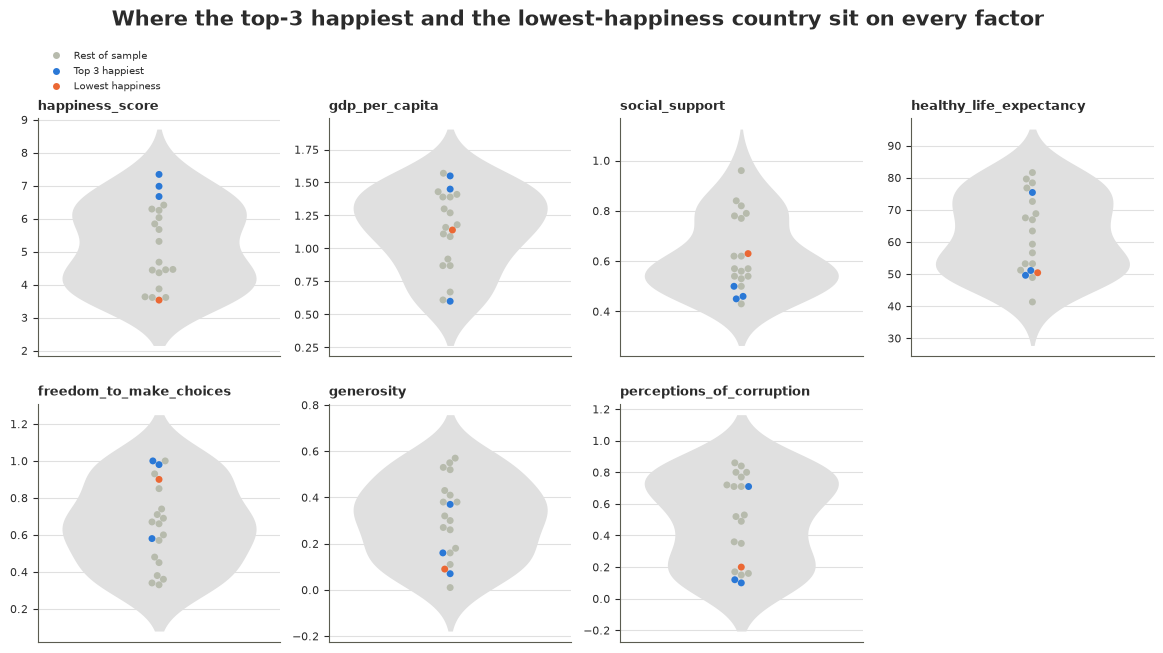

In [10]:
import seaborn as sns

role = np.select(
    [df['country'].isin(top3), df['country'] == lowest_country],
    ['Top 3 happiest', 'Lowest happiness'],
    default='Rest of sample',
)
role_palette = {'Top 3 happiest': PALETTE['accent'], 'Lowest happiness': PALETTE['alert'],
                 'Rest of sample': PALETTE['context']}

factor_cols = df.select_dtypes(include='number').columns
ncols = 4
nrows = -(-len(factor_cols) // ncols)  # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 3.4 * nrows))
axes = axes.flatten()

for i, (ax, col) in enumerate(zip(axes, factor_cols)):
    # inner=None: the violin is a KDE of the shape only, not a boxplot overlay -- with
    # n=20 the dots are the real data, the violin is a smoothing convenience.
    sns.violinplot(y=df[col], ax=ax, color=PALETTE['grid'], inner=None, linewidth=0)
    sns.swarmplot(y=df[col], hue=role, palette=role_palette, ax=ax, size=5,
                  legend=(i == 0))
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('')
    ax.set_xticks([])

if axes[0].get_legend() is not None:
    axes[0].legend(loc='upper left', bbox_to_anchor=(0, 1.32), fontsize=7, frameon=False)

for ax in axes[len(factor_cols):]:
    ax.set_visible(False)

fig.suptitle('Where the top-3 happiest and the lowest-happiness country sit on every factor',
             y=1.04)
save_fig(fig, '02_factor_profiles')
plt.show()

### Reading

Freedom is not the only place South Africa looks like the top-3, not the bottom:
`social_support` is 0.63, **higher than all three** happiest countries (Canada 0.46,
Finland 0.45, Brazil 0.50). On `healthy_life_expectancy` South Africa (50.4) sits close to
Canada (49.6) and Brazil (51.1), not at the bottom of the sample. Only
`perceptions_of_corruption` (0.20) and `generosity` (0.09) land it nearer the low end. So
the freedom anomaly is not a one-off quirk of a single column: on several factors this
low-happiness country looks similar to, or better than, the countries ranked happiest,
which is more evidence for the same conclusion the correlation panel already gave — in
this sample, these recorded factors do not line up with the happiness ranking.

saved outputs/figures/02_freedom_lowest_vs_average.png


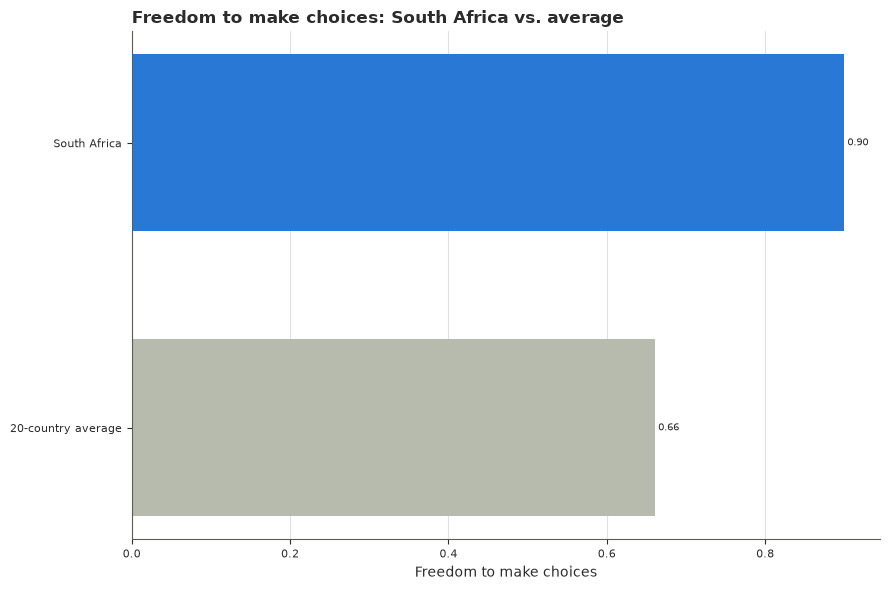

South Africa freedom: 0.90  |  20-country average: 0.66


In [11]:
# freedom_mean kept unrounded — the single source of truth for this number, so it can't
# drift into two different roundings the way Activity 1's notebook did (0.65 vs 0.66).
freedom_mean = df['freedom_to_make_choices'].mean()
lowest_freedom = df.loc[df['country'] == lowest_country, 'freedom_to_make_choices'].iloc[0]

fig, ax = ranked_bar(['20-country average', lowest_country],
                      [freedom_mean, lowest_freedom],
                      subject=[lowest_country],
                      title=f'Freedom to make choices: {lowest_country} vs. average',
                      xlabel='Freedom to make choices', value_fmt='{:.2f}')
save_fig(fig, '02_freedom_lowest_vs_average')
plt.show()

print(f'{lowest_country} freedom: {lowest_freedom:.2f}  |  20-country average: {freedom_mean:.2f}')

### Reading

South Africa's freedom score (0.90) sits well above the 20-country average (0.66) — the
opposite of what a naive read of "lowest happiness" might predict. But per the correlation
panel above, `freedom_to_make_choices` is one of the *weakest* correlates of happiness in
this sample (r ≈ 0.08). This single-country comparison is not evidence that freedom drives
happiness, here or generally — it is one data point next to a near-zero overall
relationship, and it is reported as exactly that: an interesting anomaly, not a causal
finding.

## DECISION 11 — Presentation layer

A dashboard is not always the right output for every audience.

- **Choice:** both a static PNG dashboard (Matplotlib) and an interactive HTML dashboard
  (Plotly), combining the three panels above into one figure each.
- **Why:** the assignment brief explicitly requires demonstrating both Matplotlib and
  Plotly on this task — that is the actual reason for building two dashboards, not a
  real reader's need to hover for exact values. Stated plainly rather than inventing a
  stakeholder who needs interactivity. The graded, primary deliverable stays the executed
  notebook plus `reports/W4Act2.md`.

saved outputs/figures/02_dashboard_static.png


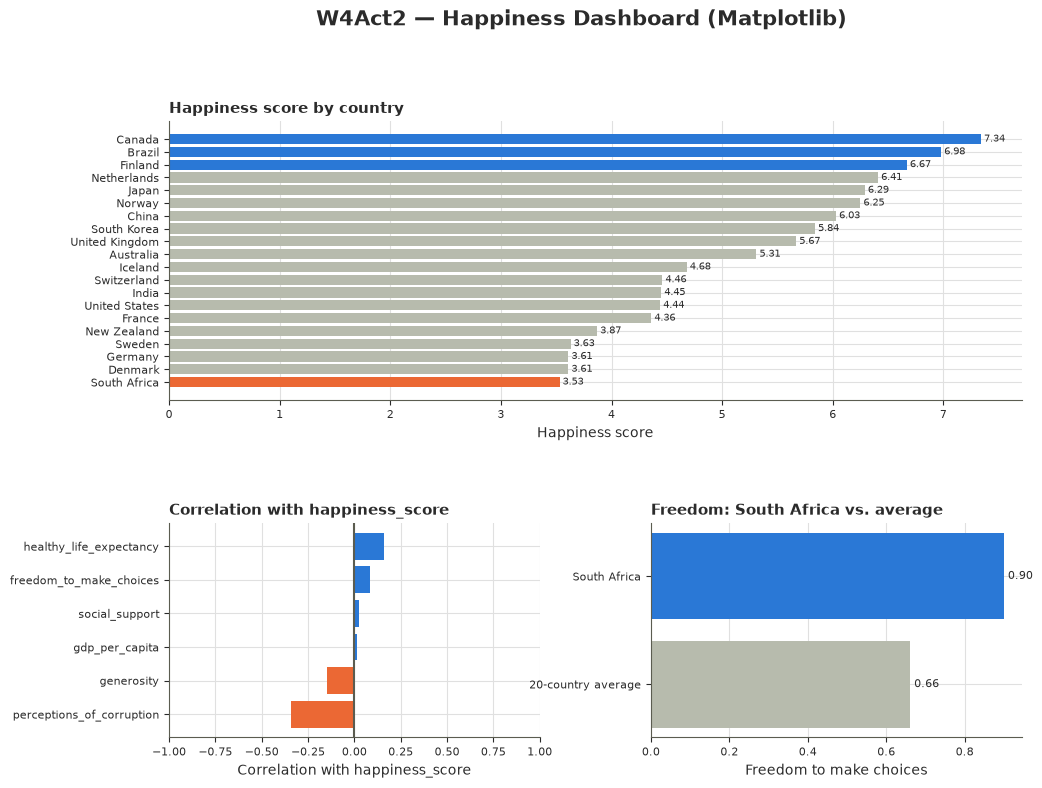

In [12]:
from src.visualization.presentation import build_dashboard
from src.visualization.theme import highlight, diverging

# build_dashboard's draw_fn(ax) callables draw directly onto a shared axes — but none of
# ranked_bar/correlation_bars accept ax=, since each creates its own standalone figure
# internally. So the three panels below inline the same bar-drawing logic those functions
# use (sort, color via highlight()/diverging(), annotate), rather than calling them and
# discarding their own throwaway figures. Known, minor, unavoidable duplication given the
# current src/ API — theme.highlight/theme.diverging themselves ARE reused as-is.

def draw_ranking(ax):
    order = np.argsort(df['happiness_score'].values)
    labels = df['country'].values[order]
    values = df['happiness_score'].values[order]
    ax.barh(labels, values, color=highlight(labels, top3, [lowest_country]))
    for i, v in enumerate(values):
        ax.text(v, i, f' {v:.2f}', va='center', fontsize=7)
    ax.set_xlabel('Happiness score')

def draw_correlation(ax):
    s = top.sort_values()
    ax.barh(s.index, s.values, color=diverging(s.values))
    ax.axvline(0, color=PALETTE['rule'])
    ax.set_xlim(-1, 1)
    ax.set_xlabel(f'Correlation with {TARGET}')

def draw_freedom(ax):
    labels = ['20-country average', lowest_country]
    values = [freedom_mean, lowest_freedom]
    ax.barh(labels, values, color=highlight(labels, [lowest_country]))
    for i, v in enumerate(values):
        ax.text(v, i, f' {v:.2f}', va='center', fontsize=8)
    ax.set_xlabel('Freedom to make choices')

fig, axes = build_dashboard(
    [(draw_ranking, 'Happiness score by country'),
     (draw_correlation, f'Correlation with {TARGET}'),
     (draw_freedom, f'Freedom: {lowest_country} vs. average')],
    title='W4Act2 — Happiness Dashboard (Matplotlib)')
save_fig(fig, '02_dashboard_static')
plt.show()

In [13]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from src.paths import DASHBOARDS

# Built directly with make_subplots rather than presentation.plotly_dashboard() this
# time: that helper is a good minimal default, but a dashboard meant to stand alone for
# someone unfamiliar with the project needs a legend/context annotation, descriptive
# hover text, and a fixed larger size for a sharp PNG export -- none of which the
# generic helper's fixed layout takes parameters for.

order = np.argsort(df['happiness_score'].values)
ranking_labels = df['country'].values[order]
ranking_values = df['happiness_score'].values[order]
ranking_colors = highlight(ranking_labels, top3, [lowest_country])

s = top.sort_values()
corr_colors = diverging(s.values)

freedom_labels = ['20-country average', lowest_country]
freedom_values = [freedom_mean, lowest_freedom]
freedom_colors = highlight(freedom_labels, [lowest_country])

plotly_fig = make_subplots(
    rows=2, cols=2,
    specs=[[{'colspan': 2}, None], [{}, {}]],
    row_heights=[0.55, 0.45],
    subplot_titles=('Happiness score by country',
                     'Correlation of each factor with happiness',
                     f'Freedom to make choices: {lowest_country} vs. average'),
    vertical_spacing=0.17, horizontal_spacing=0.12,
)

plotly_fig.add_trace(go.Bar(
    y=ranking_labels, x=ranking_values, orientation='h', marker_color=ranking_colors,
    hovertemplate='<b>%{y}</b><br>Happiness score: %{x:.2f}<extra></extra>',
), row=1, col=1)

plotly_fig.add_trace(go.Bar(
    y=s.index, x=s.values, orientation='h', marker_color=corr_colors,
    hovertemplate='<b>%{y}</b><br>Correlation with happiness: %{x:.3f}<extra></extra>',
), row=2, col=1)

plotly_fig.add_trace(go.Bar(
    y=freedom_labels, x=freedom_values, orientation='h', marker_color=freedom_colors,
    text=[f'{v:.2f}' for v in freedom_values], textposition='outside',
    hovertemplate='<b>%{y}</b><br>Freedom score: %{x:.2f}<extra></extra>',
), row=2, col=2)

plotly_fig.update_xaxes(title_text='Happiness score (0-10 scale)', row=1, col=1)
plotly_fig.update_xaxes(title_text='Pearson correlation coefficient', range=[-1, 1], row=2, col=1)
plotly_fig.update_xaxes(title_text='Freedom to make choices (0-1 scale)', range=[0, 1], row=2, col=2)
plotly_fig.add_vline(x=0, line_color=PALETTE['rule'], row=2, col=1)

# Subtitle split across three short lines -- one long line clips against the figure
# width instead of wrapping, since Plotly titles don't auto-wrap.
subtitle_lines = [
    '20 countries · no missing values · 0 outliers flagged by IQR/Z-score',
    'Blue = top-3 happiest countries, or a positive correlation',
    'Orange = lowest-happiness country, or a negative correlation · Gray = rest of sample',
]
plotly_fig.update_layout(
    template='plotly_white', showlegend=False, height=980, width=1150,
    margin=dict(l=150, r=40, t=190, b=90),
    title=dict(
        text='<b>W4Act2 -- World Happiness Dashboard</b><br>'
             + '<br>'.join(f'<sup>{line}</sup>' for line in subtitle_lines),
        x=0.02, xanchor='left',
    ),
)
plotly_fig.add_annotation(
    text=('Source: data/raw/world_happiness_dataset.csv · one row per country · '
          'source/period not stated by the file'),
    xref='paper', yref='paper', x=0, y=-0.13, showarrow=False,
    font=dict(size=10, color=PALETTE['rule']), align='left',
)

DASHBOARDS.mkdir(parents=True, exist_ok=True)
html_path = DASHBOARDS / 'W4Act2_dashboard.html'
plotly_fig.write_html(html_path, include_plotlyjs='cdn')
print(f'wrote {html_path}')

try:
    png_path = DASHBOARDS / 'W4Act2_dashboard.png'
    plotly_fig.write_image(png_path, scale=3)
    print(f'wrote {png_path}')
except Exception as exc:
    print(f'PNG export skipped ({exc})')

plotly_fig.show()

wrote /Users/ericsmac/Documents/GitHub/MSE803-DA/W4/W4Act2/outputs/dashboards/W4Act2_dashboard.html


wrote /Users/ericsmac/Documents/GitHub/MSE803-DA/W4/W4Act2/outputs/dashboards/W4Act2_dashboard.png


Both dashboards show the same three panels and numbers: `outputs/figures/02_dashboard_static.png`
(Matplotlib, static) and `outputs/dashboards/W4Act2_dashboard.html` (Plotly, interactive —
hover any bar for its exact value). The Plotly version also carries its own context for a
reader who has not seen this notebook: a subtitle explaining the color coding and dataset
scope, a source line, axis titles on every panel, and a larger canvas for a sharper
`.png` export.

## Findings so far

- Top 3 happiest: Canada (7.34), Brazil (6.98), Finland (6.67). Lowest: South Africa
  (3.53), clearly separated from the rest of the sample.
- South Africa's freedom score (0.90) sits well above the 20-country average (0.66) — but
  freedom is one of the weakest correlates of happiness overall (r ≈ 0.08), so this is an
  interesting single-country anomaly, not evidence of a general relationship.
- No factor correlates strongly with happiness in this sample: strongest is
  `perceptions_of_corruption` at r ≈ −0.34; everything else is under 0.16 in magnitude.
- 01's outlier screen checked every column with both IQR and Z-score, confirmed the
  result visually (box plots and a Z-score dot plot) and at the row level: 0 values
  flagged by either method, so no row was excluded.
- `GROUP` left unset — `country` is a near-unique identifier, not a categorical factor with
  more than one row per level.
- Presentation: `outputs/figures/02_dashboard_static.png` (Matplotlib) and
  `outputs/dashboards/W4Act2_dashboard.html` (Plotly), per DECISION 11 above.

**Next stage:** stop here — description answers the brief; this question does not need a
hypothesis test or a predictive model.